In [ ]:
# Standard library imports
import os
import io
import sys
import itertools
import random

# Third-party imports
import numpy as np
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from scipy.ndimage import zoom

# PyTorch imports
import torch
from torch import nn
from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
import torchvision
from torchvision.utils import make_grid
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torchvision import models
from torchsummary import summary
from torchsummary import summary

In [ ]:
# Live plotting packages
!pip install livelossplot
from tqdm import tqdm
from livelossplot import PlotLosses

# Free GPU Memory Efficinetly
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
# Mount drive
from google.colab import drive, runtime
drive.mount('/content/drive')

# Get device
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
    device = 'cpu'

# Function to fix random seed
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled   = True

    return True

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cuda installed! Running on GPU!


In [ ]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

train.h5:   2%|2         | 220M/10.7G [00:00<?, ?B/s]

events.csv:   0%|          | 0.00/782k [00:00<?, ?B/s]

'data/events.csv'

In [ ]:
def load_ids(file_name="data/events.csv", n=10):
    "Load ids"
    df = pd.read_csv(file_name)
    ids = df.id.unique()
    ids = np.random.choice(ids, size=n, replace=False)
    return ids

def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

def upsample(data, target_shape=(384, 384)):
    """
    Upsample data to target resolution.
    :param data: Original data, shape (height, width).
    :param target_shape: Target resolution (height, width).
    :return: Upsampled data.
    """
    zoom_factors = (target_shape[0] / data.shape[0], target_shape[1] / data.shape[1], 1)
    return zoom(data, zoom_factors, order=1)


def normalise_sample(img):
    """
    Normalise image to [0, 1] range.
    """
    img = img - np.min(img)
    img = img / np.max(img)
    return img


def get_targets(event):
    """
    Maps lightning strikes of an event into a sparse target mask.
    Returned targets represent lightning strikes map for each frame (36) of the event.

    :rtype: list of sparse matrices of shape (384, 384) for each frame
    """
    t = event["lght"][:,0]
    target = np.zeros((384, 384, 36))

    for ti in range(36):
        # Find which lightning strikes fall in current frame and store their coodinates
        f = (t >= ti*5*60) & (t < ti*5*60 + 5*60)
        xs = event["lght"][f,3]
        ys = event["lght"][f,4]

        for x, y in zip(xs, ys):
            target[int(x), int(y), ti] += 1

    return target


In [ ]:
class LightningDataset(Dataset):
    def __init__(self, ids, target_max=100):
        self.target_max = target_max
        self.events = [load_event(id) for id in ids]
        self.targets = [get_targets(event) for event in self.events]

        # Mean and standard deviation of the dataset for normalisation
        self.targets = torch.tensor(self.targets, dtype=torch.float16)
        self.std = torch.std(self.targets)
        self.mean = torch.mean(self.targets)

        for event in self.events:
            # Normalise Images
            event["vis"] = normalise_sample(event["vis"])
            event["vil"] = normalise_sample(event["vil"])
            event["ir069"] = normalise_sample(event["ir069"])
            event["ir069"] = normalise_sample(event["ir069"])
            # Upsample Images
            event["vis"] = upsample(event["vis"])
            event["vil"] = upsample(event["vil"])
            event["ir069"] = upsample(event["ir069"])
            event["ir107"] = upsample(event["ir107"])

    def __len__(self):
        "Returns total number of samples"
        return len(self.events)

    def __getitem__(self, idx):
        "Returns a single sample from the dataset"
        # Load event from id
        event = self.events[idx]

        # Get the targets and normalise
        target = self.targets[idx]
        target = (target - self.mean) / self.std

        # Convert to PyTorch tensors and stack the image types into a single tensor
        vis = torch.tensor(event["vis"], dtype=torch.float16)
        vil = torch.tensor(event["vil"], dtype=torch.float16)
        ir069 = torch.tensor(event["ir069"], dtype=torch.float16)
        ir107 = torch.tensor(event["ir107"], dtype=torch.float16)

        # Stack the inputs to form a single tensor of shape (36, 4, 384, 384)
        X = torch.stack([vis, ir069, ir107, vil], dim=0).permute(3, 0, 1, 2)

        # Convert dense_targets to PyTorch tensor and ensure shape is (36, 1, 384, 384)
        Y = target.permute(2, 0, 1).unsqueeze(1)

        return X, Y

In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size, padding):
        super(ConvLSTMCell, self).__init__()
        self.hidden_channels = hidden_channels

        self.conv = nn.Conv2d(
            in_channels=input_channels + hidden_channels,
            out_channels=4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x, hidden):
        h_prev, c_prev = hidden  # Previous hidden and cell state

        combined = torch.cat([x, h_prev], dim=1)  # Concatenate along channel dimension
        conv_output = self.conv(combined)

        i, f, g, o = torch.chunk(conv_output, chunks=4, dim=1)  # Split into 4 gates
        i = torch.sigmoid(i)  # Input gate
        f = torch.sigmoid(f)  # Forget gate
        g = torch.tanh(g)      # Cell gate
        o = torch.sigmoid(o)  # Output gate

        c_next = f * c_prev + i * g  # New cell state
        h_next = o * torch.tanh(c_next)  # New hidden state

        return h_next, c_next

class ConvLSTM(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size, num_layers, padding=1):
        super(ConvLSTM, self).__init__()
        self.num_layers = num_layers

        self.layers = nn.ModuleList([
            ConvLSTMCell(
                input_channels=input_channels if i == 0 else hidden_channels,
                hidden_channels=hidden_channels,
                kernel_size=kernel_size,
                padding=padding
            ) for i in range(num_layers)
        ])

        self.final_conv = nn.Conv2d(hidden_channels, 1, kernel_size=1)

    def forward(self, x, hidden=None):
        batch_size, seq_len, _, height, width = x.shape

        if hidden is None:
            hidden = [(
                torch.zeros(batch_size, self.layers[i].hidden_channels, height, width, device=x.device),
                torch.zeros(batch_size, self.layers[i].hidden_channels, height, width, device=x.device)
            ) for i in range(self.num_layers)]

        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :, :, :]
            for i, layer in enumerate(self.layers):
                hidden[i] = layer(x_t, hidden[i])
                x_t = hidden[i][0]

            x_t = self.final_conv(x_t)
            outputs.append(x_t.unsqueeze(1))

        return torch.cat(outputs, dim=1), hidden


In [ ]:
def train(model, optimizer, criterion, data_loader):
    model.train()
    train_loss = 0.

    for input, target in data_loader:
      input, target = input.to(device), target.to(device)
      optimizer.zero_grad()
      output, hidden = model(input)
      loss = criterion(output, target)
      loss.backward()
      train_loss += loss*input.size(0)
      optimizer.step()
    train_loss = train_loss / len(data_loader.dataset)
    return train_loss

def valid(model, criterion, data_loader):
    model.eval()
    valid_loss = 0.
    with torch.no_grad():
        for input, target in data_loader:
            input, target = input.to(device), target.to(device)
            output, hidden = model(input)
            loss = criterion(output, target)
            valid_loss += loss*input.size(0)
        valid_loss = valid_loss / len(data_loader.dataset)
        return valid_loss

def train_loop(model, nepochs, optimizer, criterion, train_loader, val_loader):
  liveloss = PlotLosses()
  for i in range(nepochs):
      train_loss = train(model, optimizer, criterion, train_loader)
      val_loss = valid(model, criterion, val_loader)
      logs = {}
      logs['' + 'log loss'] = train_loss.item()
      logs['val_' + 'log loss'] = val_loss.item()
      liveloss.update(logs)
      liveloss.draw()

# Custom Total Absolute Error Loss
class TotalAbsoluteError(nn.Module):
    def __init__(self):
        super(TotalAbsoluteError, self).__init__()

    def forward(self, input, target):
        # Compute the absolute error
        absolute_error = torch.abs(input - target)
        # Sum up all the absolute errors
        total_absolute_error = absolute_error.sum()
        return total_absolute_error


In [ ]:
# Set Parameters
no_ids = 50
lr = 1e-5
nepochs = 20
batch_size = 1

# Load IDs and split into train and test sets
ids = load_ids(n=no_ids)
val_ids, train_ids = train_test_split(ids, test_size=0.8)

# Initialize the dataset
train_dataset = LightningDataset(train_ids, target_max=100)
val_dataset = LightningDataset(val_ids, target_max=100)

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the model
input_channels = 4
hidden_channels = 32
kernel_size = 3
num_layers = 2
model = ConvLSTM(input_channels, hidden_channels, kernel_size, num_layers).to(device)

# Define the loss function and optimizer
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=lr)

<ipython-input-10-f546c89054e2>:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  self.targets = torch.tensor(self.targets, dtype=torch.float16)


Using device: cuda


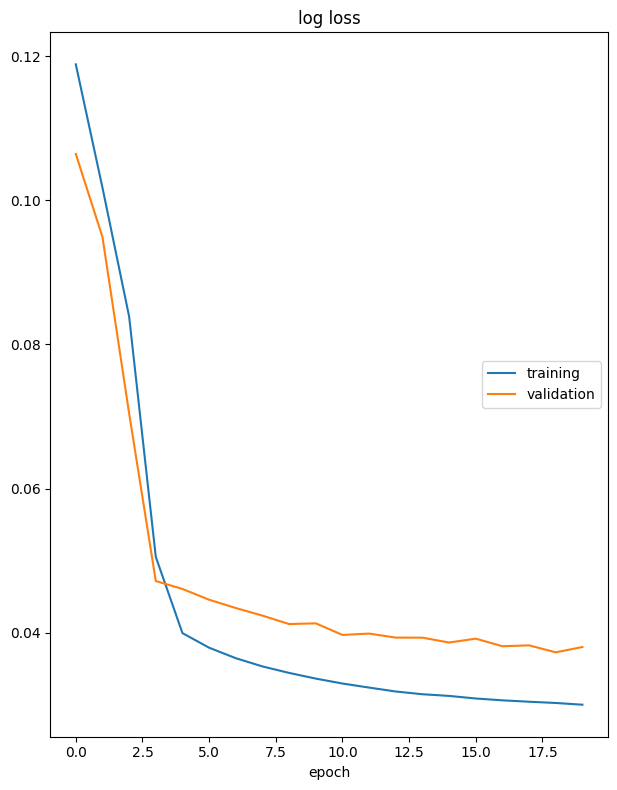

log loss
	training         	 (min:    0.030, max:    0.119, cur:    0.030)
	validation       	 (min:    0.037, max:    0.106, cur:    0.038)


In [ ]:
train_loop(model, nepochs, optimizer, criterion, train_loader, val_loader)

tensor(0.0033)


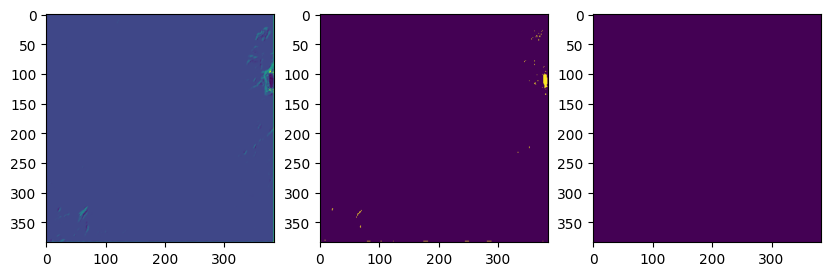

In [ ]:
# Get sample and output
event_no = 5
frame = 0
event_id = train_ids[event_no]
input, target = train_dataset[event_no][0], train_dataset[event_no][1]

target = target.unsqueeze(0)
input = input.unsqueeze(0).to(device)

output, hidden = model(input)
output = output.detach().cpu()

#Load event
event = load_event(event_id)

# Set all values each frame not equal to zero to 1
test_output = output[0, frame, 0, :, :].reshape(384, 384)
test_target = target[0, frame, 0, :, :].reshape(384, 384)

# Denormalise
test_output = test_output * train_dataset.std + train_dataset.mean

print(torch.mean(test_output))

test_output_f = torch.clone(test_output)
test_output_f[(test_output_f <= 0.003) & (test_output_f >= 0.001)] = 1

#test_output[test_output > 0.001] = 0

test_target = test_target * train_dataset.std + train_dataset.mean
test_target[ test_target >= 1 ] = 1

# Plot output vs target
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(test_output)
axs[1].imshow(test_output_f)
axs[2].imshow(test_target)

In [ ]:
# Denormalise
event_no = 0
event_output = output[0,:,0,:,:].reshape(36, 384, 384)
event_target = target[0,:,0,:,:].reshape(36, 384, 384)

event_output = event_output * train_dataset.std + train_dataset.mean
event_target = event_target * train_dataset.std + train_dataset.mean

print("### MEAN STRIKES ###")
print(f"Model output mean strikes:{torch.mean(event_output)}")
print(f"Target output mean strikes:{torch.mean(event_target)}\n")

strikes_target = torch.sum((event_target))
strikes_model = torch.sum((event_output))

mse = nn.functional.mse_loss(event_output, event_target)

# Print sum of strikes
print("### SUM OF STRIKES ###")
print(f"Model:{strikes_model}")
print(f"Target:{strikes_target}\n")

print(f"MSE:{mse}")

### MEAN STRIKES ###
Model output mean strikes:0.0001301729935221374
Target output mean strikes:2.8014183044433594e-06

### SUM OF STRIKES ###
Model:691.0123901367188
Target:14.9921875

MSE:3.3368626191077055e-06



# FRAMEWORK TO VISUALISE MODEL PREDICTIONS
1. Frame by Frame: predict_plot
2. Event GIF: predict_plot_w_gif

In [ ]:
# 1: creating a lightning maps (target) from a given lightning time series
# 2: creating a lightining time series (output) from predicted lightning maps (36 per event/sample)
def get_targets(event):
    """
    Maps lightning strikes of an event into a sparse target mask.
    Returned targets represent lightning strikes map for each frame (36) of the event.

    :rtype: list of sparse matrices of shape (384, 384) for each frame
    """
    t = event["lght"][:,0]
    target = np.zeros((384, 384, 36))

    # For each frame in the event
    for ti in range(36):
        # Find which lightning strikes fall in current frame and store their coodinates
        f = (t >= ti*5*60) & (t < ti*5*60 + 5*60)
        xs = event["lght"][f,3]
        ys = event["lght"][f,4]

        # Set the coordinates to 1 in the target tensor
        for x, y in zip(xs, ys):
            target[int(x), int(y), ti] += 1

    return target


def get_lightning_time_series(prediction):
    """
    Converts the given prediction (36 lightning maps of 36 frames of an event)
    into a ligthning time series of that event.

    :param target: list of sparse matrices of shape (384, 384, 36) representing lightning strikes map for each frame
    :rtype: lightning time series of that prediction/event.
    """
    lght = []
    n_frames = 36 # assumes 36 frames
    # lightining strike values (in the map) above masked
    # value are considered as lightnings
    mask_value = 0.003

    # For each frame in the target
    prediction = prediction.reshape(384, 384, n_frames)
    for ti in range(n_frames):
        frame = prediction[:, :, ti]
        xs, ys = np.where(frame >= mask_value)

        # For each lightning strike in the frame
        for x, y in zip(xs, ys):
            count = frame[x, y]
            count = 1 if count > 0 else 0 # only store one lightning per location for now
            for _ in range(int(count)):
                lght.append([ti * 5 * 60, 0, 0, x, y])

    lght = np.array(lght)
    return lght


In [ ]:
# create a testing framework
# given an event, predict the answer

def predict_event(event_id_idx):
  """
  Designed for Conv-LSTM arhictecture
  This predicter assumes model output: (36, 1, 384, 384)
  1 sample = 1 event (36 frames, 36 lightning maps)

  Input: id of the event to predict
  Output: predicted lightning time series of that event
  """
  # creating a dataloader for the event (+ remaining batch size)
  predict_events = [ids[idx] for idx in range(event_id_idx, batch_size)]
  predict_dataset = LightningDataset(predict_events, target_max=100)
  predict_loader = DataLoader(predict_dataset, batch_size=batch_size, shuffle=True)

  # only predicting the first sample in the batch (to match our event)
  for X_next, y_next in predict_loader:
    prediction_batch, _ = model(X_next.to(device))
    prediction_batch = prediction_batch.detach().cpu()
    break

  lightning_maps_output = prediction_batch.reshape(36, 384, 384)
  lightning_maps_output *= train_dataset.std + train_dataset.mean

  print("LIGHTNING MAP INFORMATION")
  print(torch.mean(lightning_maps_output))
  print(torch.max(lightning_maps_output))
  print(torch.min(lightning_maps_output))

  # creating lightning time series from lightning maps (36 maps per sample/event)
  ligthning_ts = get_lightning_time_series(lightning_maps_output)
  return ligthning_ts


lght = predict_event(0)
print(len(lght))


LIGHTNING MAP INFORMATION
tensor(-0.0011)
tensor(0.0072)
tensor(-0.0062)
10125


In [ ]:
""" EVENT PLOTS WITH PREDICTIONS PER FRAME """
def plot_event_w_predictions(event, predicted_lght, frame=0):
    """
    Plots the event with 4 input image channels
    Plots target/label lightning strikes of the event
    Plots predicted/output lightning strikes of the event
    """

    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    if len(predicted_lght) != 0: t_pred = predicted_lght[:,0]

    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        if len(predicted_lght) != 0: f_pred =  (t_pred >= ti*5*60 - 2.5*60) & (t_pred < ti*5*60 + 2.5*60)

        fig,axs = plt.subplots(1,5,figsize=(16,5))
        fig.suptitle(f"Event: {id}, Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)

        axs[4].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[4].set_title('Radar Predicted Strikes')
        if len(predicted_lght) != 0:
          axs[4].scatter(predicted_lght[f_pred,3], predicted_lght[f_pred,4], marker="x", s=30, c="tab:red")
          axs[4].set_xlim(0,384), axs[3].set_ylim(384,0)
        plt.show()

    plot_frame(frame)


""" EVENT PLOT WITH PREDICTIONS PER EVENT (GIF) """
def make_gif(outfile, files, fps=10, loop=0):
    "Helper function for saving GIFs"
    imgs = [PIL.Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='gif', append_images=imgs[1:],
                 save_all=True, duration=int(1000/fps), loop=loop)
    im = IPython.display.Image(filename=outfile)
    im.reload()
    return im


def plot_event_w_predictions_gif(event, predicted_lgth, output_gif=False, save_gif=False):
    t = event["lght"][:,0]# time of lightning strike (in seconds relative to first frame)
    if len(predicted_lght) != 0: t_pred = predicted_lght[:,0]

    def plot_frame(ti):
        f = (t >= ti*5*60 - 2.5*60) & (t < ti*5*60 + 2.5*60)# find which lightning strikes fall in current frame
        if len(predicted_lght) != 0: f_pred =  (t_pred >= ti*5*60 - 2.5*60) & (t_pred < ti*5*60 + 2.5*60)

        fig,axs = plt.subplots(1,5,figsize=(16,5))
        fig.suptitle(f"Event: {id}, Frame: {ti}, Time: {ti*5} min")
        axs[0].imshow(event["vis"][:,:,ti], vmin=0, vmax=10000, cmap="grey"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:,:,ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:,:,ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar')
        axs[3].scatter(event["lght"][f,3], event["lght"][f,4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0,384), axs[3].set_ylim(384,0)

        axs[4].imshow(event["vil"][:,:,ti], vmin=0, vmax=255, cmap="turbo"), axs[4].set_title('Radar Predicted Strikes')
        if len(predicted_lght) != 0:
          axs[4].scatter(predicted_lght[f_pred,3], predicted_lght[f_pred,4], marker="x", s=30, c="tab:red")
          axs[4].set_xlim(0,384), axs[3].set_ylim(384,0)

        if output_gif:
            file = f"_temp_{id}_{ti}.png"
            fig.savefig(file, bbox_inches="tight", dpi=150, pad_inches=0.02, facecolor="white")
            plt.close()
        else:
            plt.show()

    if output_gif:
        for ti in range(36): plot_frame(ti)
        im = make_gif(f"{id}.gif", [f"_temp_{id}_{ti}.png" for ti in range(36)])
        for ti in range(36): os.remove(f"_temp_{id}_{ti}.png")
        IPython.display.display(im)
        if not save_gif: os.remove(f"{id}.gif")
    else:
        plot_frame(0)
        plot_frame(17)
        plot_frame(34)


In [ ]:
# predict an event, plot the event and predictions
def predict_plot(event_id_idx):
  """
  Predicts and plots the given event based on event id index.
  """

  # loading the event
  m_id = ids[event_id_idx]
  m_event = load_event(m_id)
  # predicting the event, getting predicted lightining time series
  predicted_lght = predict_event(event_id_idx)
  print("number of predicted lightnings: ", len(predicted_lght))

  # plotting the event along with predicted lightining time series
  plot_event_w_predictions(m_event, predicted_lght, frame=0)


def predict_plot_w_gif(event_id_idx):
    """
    Predicts and plots a gif the given event based on event id index.
    """

    # loading the event
    m_id = ids[event_id_idx]
    m_event = load_event(m_id)
    # predicting the event, getting predicted lightining time series
    predicted_lght = predict_event(event_id_idx)
    print("number of predicted lightnings: ", len(predicted_lght))

    # plotting the event along with predicted lightining time series
    plot_event_w_predictions_gif(m_event, predicted_lght, output_gif=True, save_gif=True)

LIGHTNING MAP INFORMATION
tensor(-0.0011)
tensor(0.0072)
tensor(-0.0062)
number of predicted lightnings:  10125


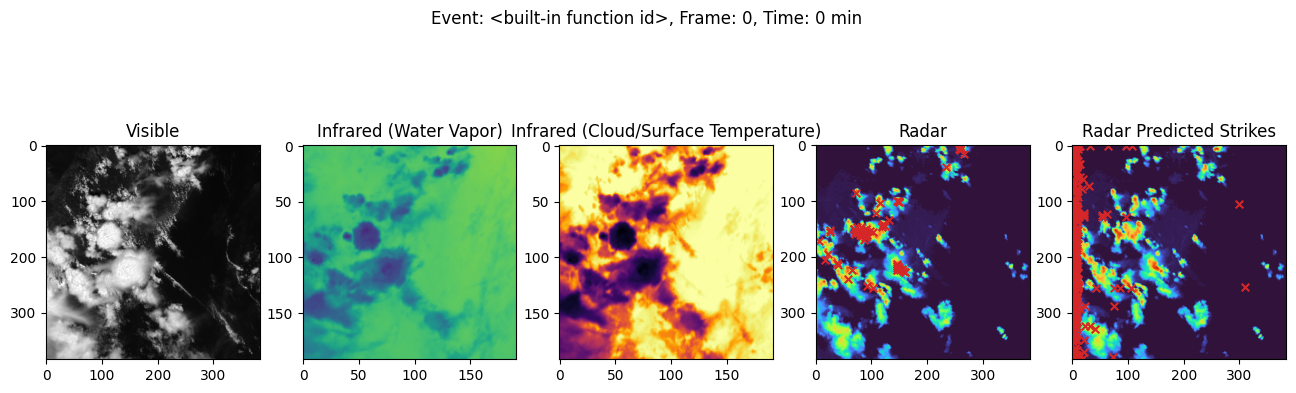

In [ ]:
predict_plot(0) # predicting and plotting the event with event id idx = 0
#predict_plot_w_gif(0) # predicting and plotting the event gif with even id idx = 0